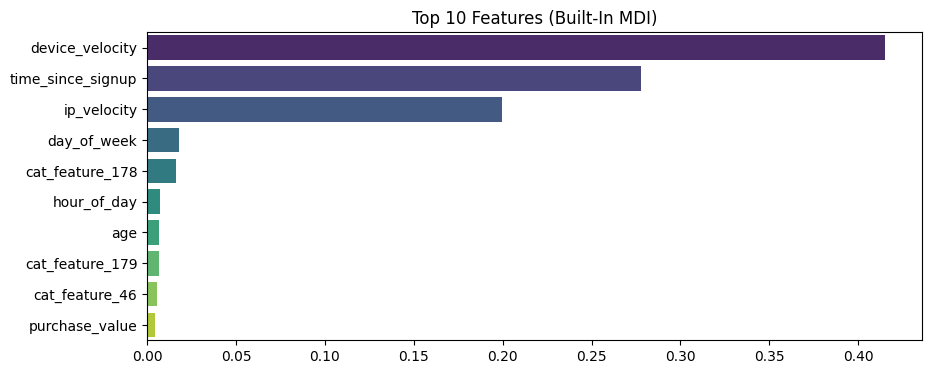

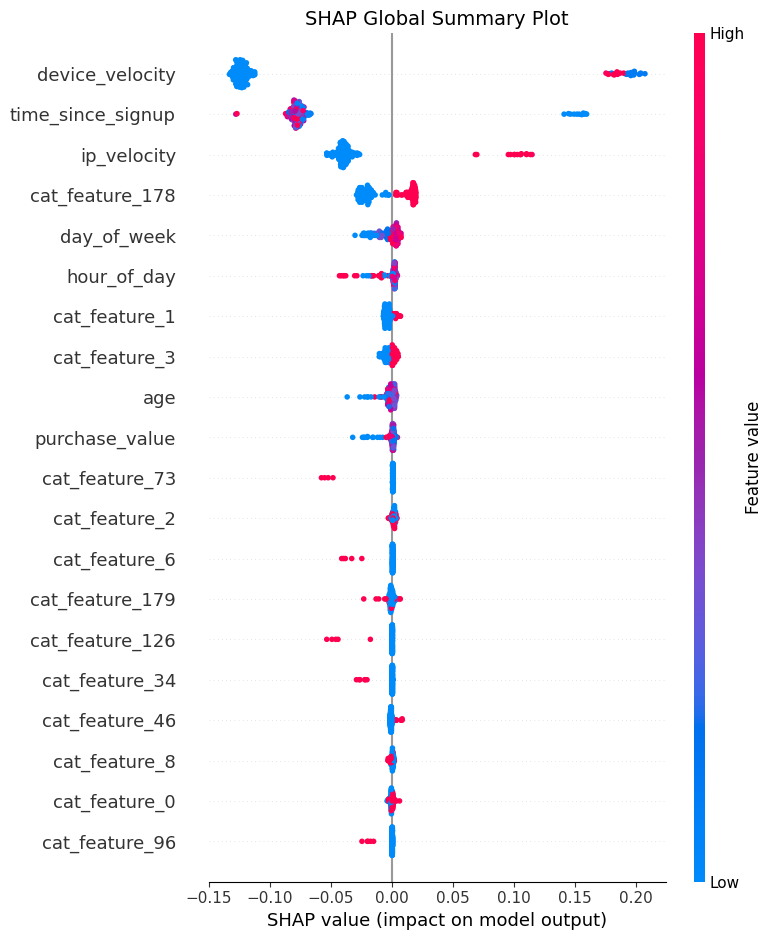

<Figure size 1200x300 with 0 Axes>

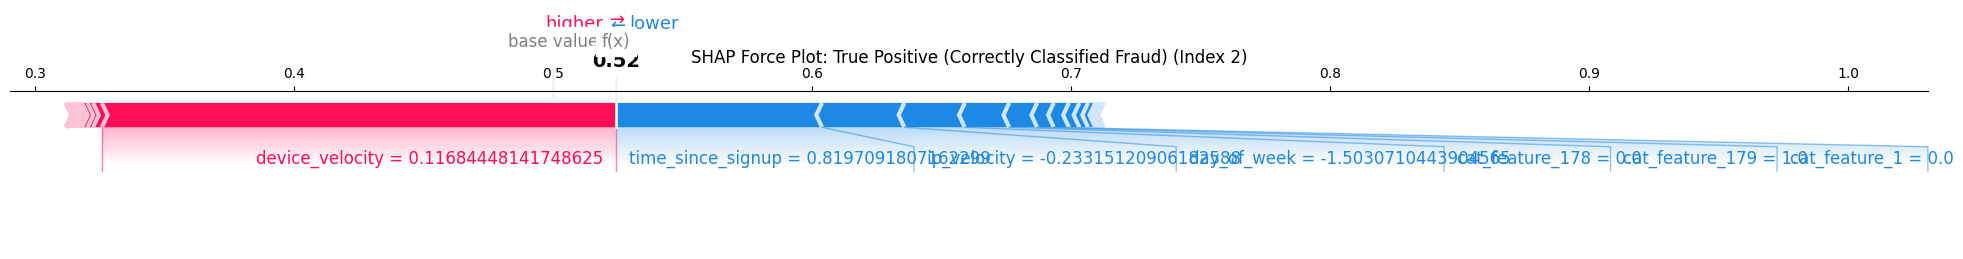

<Figure size 1200x300 with 0 Axes>

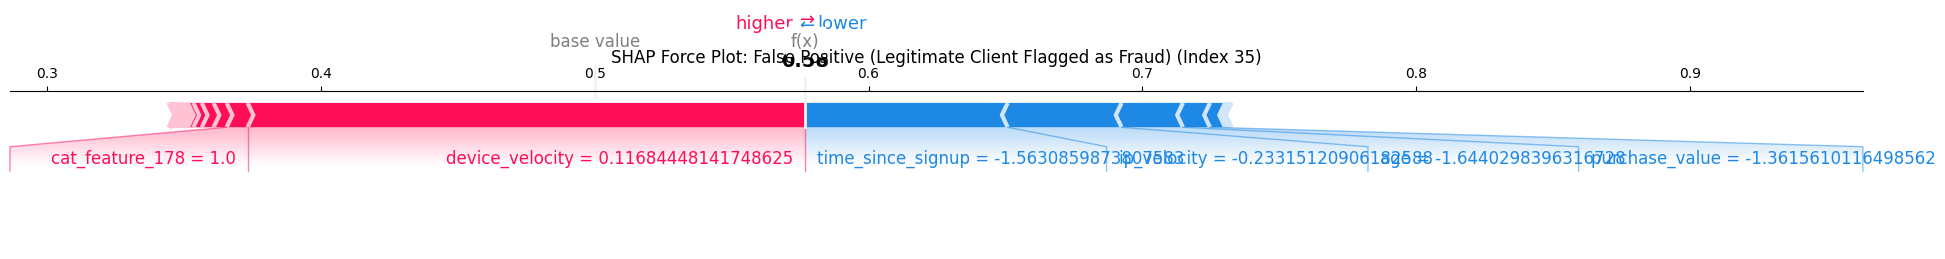

<Figure size 1200x300 with 0 Axes>

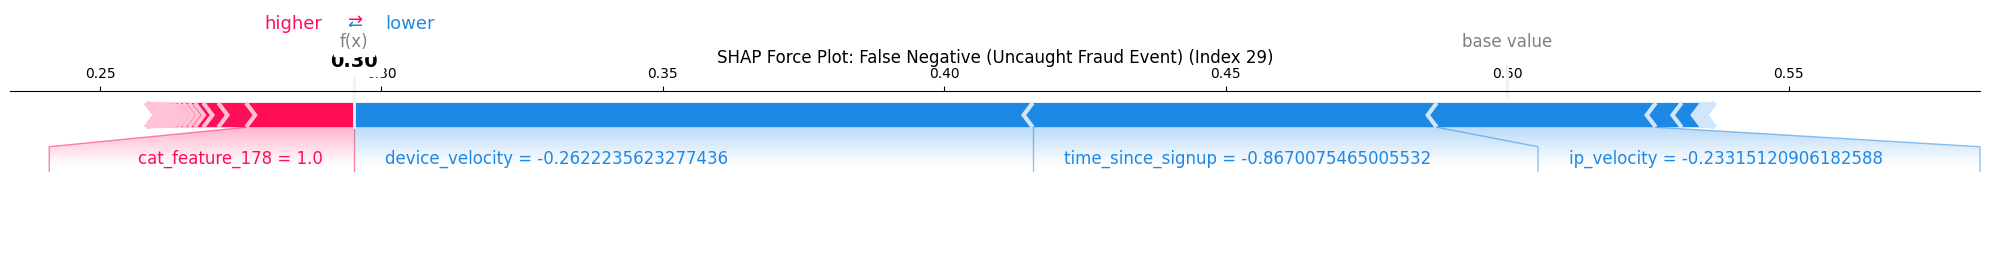

In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
warnings.filterwarnings('ignore')

# Load Model & Scaled Test Matrix
rf_model = joblib.load('../models/Fraud_Data_random_forest.pkl')
X_test = np.load('../data/processed/X_test_f.npy')
y_test = np.load('../data/processed/y_test_f.npy')

# Re-establish placeholder names (Numerical + Cat dummies)
num_cols = ['purchase_value', 'age', 'hour_of_day', 'day_of_week', 'time_since_signup', 'device_velocity', 'ip_velocity']
feature_names = num_cols + [f"cat_feature_{i}" for i in range(X_test.shape[1] - len(num_cols))]

# ==========================================
# 1. Built-In Feature Importance (Top 10)
# ==========================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 4))
sns.barplot(x=importances[indices[:10]], y=[feature_names[i] for i in indices[:10]], hue=[feature_names[i] for i in indices[:10]], palette='viridis', legend=False)
plt.title('Top 10 Features (Built-In MDI)')
plt.show()

# ==========================================
# 2. SHAP Analysis & Force Plots (Fixed Type handling)
# ==========================================
# Background sample calculation (speeds up processing)
shap.initjs()
explainer = shap.TreeExplainer(rf_model)

# Sample to isolate TP, FP, FN cases from prediction array
preds = rf_model.predict(X_test)
tp_idx = np.where((preds == 1) & (y_test == 1))[0][0]
fp_idx = np.where((preds == 1) & (y_test == 0))[0][0]
fn_idx = np.where((preds == 0) & (y_test == 1))[0][0]

# Sample subset of test partition to compute collective values
np.random.seed(42)
sample_idx = np.concatenate([np.random.choice(len(X_test), 200, replace=False), [tp_idx, fp_idx, fn_idx]])
X_sample = X_test[sample_idx]

# Compute SHAP values for sample
shap_values_sample = explainer.shap_values(X_sample)

# --- Robust Multi-output Array Shape Alignment ---
if isinstance(shap_values_sample, list):
    # Old SHAP API returns a list of length 2 [class 0, class 1]
    shap_val_class1_sample = shap_values_sample[1]
elif isinstance(shap_values_sample, np.ndarray):
    if len(shap_values_sample.shape) == 3:
        # New SHAP API returns a 3D array: (samples, features, classes)
        # We extract all samples, all features, for Class 1 index
        shap_val_class1_sample = shap_values_sample[:, :, 1]
    else:
        # If it's already 2D, use it as is
        shap_val_class1_sample = shap_values_sample
else:
    # Handle SHAP Explanation objects if applicable
    shap_val_class1_sample = shap_values_sample

# Generate Global SHAP Summary Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_val_class1_sample, X_sample, feature_names=feature_names, show=False)
plt.title("SHAP Global Summary Plot", fontsize=14)
plt.tight_layout()
plt.show()

# --- Corrected Expected Value Extraction ---
# Random Forests return base values for [Class 0, Class 1]. We explicitly need index 1.
if hasattr(explainer.expected_value, "__len__") and len(explainer.expected_value) == 2:
    base_value_class1 = explainer.expected_value[1]
else:
    base_value_class1 = explainer.expected_value

# Refactored local force plot function
def display_force_plot(idx, label):
    # Compute local row values for just this single instance
    row_shap = explainer.shap_values(X_test[idx:idx+1])
    
    # Extract Class 1 values cleanly
    if isinstance(row_shap, list):
        row_shap_class1 = row_shap[1][0] # Index 1 for Class 1, Index 0 for first row
    elif isinstance(row_shap, np.ndarray) and len(row_shap.shape) == 3:
        row_shap_class1 = row_shap[0, :, 1] # Row 0, all features, Class 1
    else:
        row_shap_class1 = row_shap[0] # Fallback for 2D outputs
    
    plt.figure(figsize=(12, 3))
    shap.force_plot(
        base_value_class1, 
        row_shap_class1, 
        X_test[idx], 
        feature_names=feature_names, 
        matplotlib=True, 
        show=False
    )
    plt.title(f"SHAP Force Plot: {label} (Index {idx})", pad=20)
    plt.tight_layout()
    plt.show()

# Generate the three specified Force Plots safely
display_force_plot(tp_idx, "True Positive (Correctly Classified Fraud)")
display_force_plot(fp_idx, "False Positive (Legitimate Client Flagged as Fraud)")
display_force_plot(fn_idx, "False Negative (Uncaught Fraud Event)")